In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("train.csv",header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,69769,-946,0.1613,0.7960,Panl,N,Bus2,0.0742,0,2,...,1.0,-4670,0.9851,0.0000,0,Mard,0.0,0.3333,0,0
1,236977,-92,NaN,NaN,NaN,Y,Othr,NaN,0,3,...,NaN,-1994,NaN,NaN,0,Mard,0.0,NaN,0,0
2,168821,-1646,0.1124,0.8504,Panl,N,Bus3,0.0387,0,2,...,2.0,-2842,0.9891,0.0000,0,Sind,0.0,0.3750,0,1
3,94708,-1651,0.0263,NaN,Blok,N,Bus3,NaN,0,2,...,4.0,-1345,0.9682,0.0000,0,Sind,0.0,0.0417,0,1
4,84556,-977,NaN,NaN,NaN,N,Rest,NaN,0,2,...,NaN,-852,NaN,NaN,0,Sind,0.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246003,248161,-595,NaN,NaN,NaN,N,Bus3,NaN,0,2,...,NaN,-4420,NaN,NaN,0,Mard,0.0,NaN,0,0
246004,257069,-4334,0.1145,0.8368,Panl,N,Mede,0.1180,0,2,...,4.0,-2561,0.9881,0.0000,0,Sind,0.0,0.3333,0,0
246005,154350,365243,0.3025,0.6056,Mixd,N,XNAA,0.2233,0,2,...,1.0,-4636,0.9712,0.0631,0,Cive,0.0,0.1667,0,0
246006,148183,365243,NaN,NaN,NaN,N,XNAA,NaN,0,3,...,5.0,-4636,NaN,NaN,0,Mard,0.0,NaN,0,1


In [3]:
np.info(df)

Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order.

    .. versionchanged:: 0.25.0
       If data is a list of dicts, column order follows insertion-order.

index : Index or array-like
    Index to use for resulting frame. Will default to RangeIndex if
    no indexing information part of input data and no index provided.
columns : Index or array-like
    Column labels to use for resulting frame when data does not have them,
    defaulting to RangeIndex(0, 1, 2, ..., n). If data contains column labels,
    will perform

In [4]:
df.dtypes

0        int64
1        int64
2      float64
3      float64
4       object
        ...   
117     object
118    float64
119    float64
120      int64
121      int64
Length: 122, dtype: object

In [5]:
null_count = df.isnull().sum()
print(null_count)

0           0
1           0
2      143829
3      163543
4      124975
        ...  
117         0
118       811
119    122297
120         0
121         0
Length: 122, dtype: int64


In [6]:
missing_percent = null_count / len(df)
print(f"Missing percent is : {missing_percent}")
# select the columns where the percent of missing values is greater than 30%
missing_cols1 = missing_percent[missing_percent < 0.1].index.tolist()
print(missing_cols1)

Missing percent is : 0      0.000000
1      0.000000
2      0.584652
3      0.664787
4      0.508012
         ...   
117    0.000000
118    0.003297
119    0.497126
120    0.000000
121    0.000000
Length: 122, dtype: float64
[0, 1, 5, 6, 8, 9, 13, 15, 16, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 35, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 72, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 118, 120, 121]


In [7]:
numberOfMissingCols1 = len(missing_cols1)
numberOfMissingCols1

65

In [8]:
total_columns = 0
for i in df:
    total_columns += df.shape[1]
total_columns

14884

In [9]:
numberOfMissingCols1/total_columns

0.004367105616769685

In [10]:
missing_cols2 = missing_percent[missing_percent <= 0.2].index.tolist()
print(missing_cols2)

[0, 1, 5, 6, 8, 9, 12, 13, 15, 16, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 37, 40, 41, 42, 45, 46, 47, 50, 52, 53, 55, 57, 58, 62, 63, 64, 65, 66, 67, 69, 70, 71, 72, 73, 75, 76, 81, 83, 85, 90, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 112, 113, 116, 117, 118, 120, 121]


In [11]:
numberOfMissingCols2 = len(missing_cols2)
numberOfMissingCols2

72

In [12]:
numberOfMissingCols2/total_columns

0.004837409298575652

In [13]:
missing_cols3 = missing_percent[missing_percent < 0.3].index.tolist()
print(missing_cols3)

[0, 1, 5, 6, 8, 9, 12, 13, 15, 16, 19, 20, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 37, 40, 41, 42, 45, 46, 47, 50, 52, 53, 55, 57, 58, 62, 63, 64, 65, 66, 67, 69, 70, 71, 72, 73, 75, 76, 81, 83, 85, 90, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 112, 113, 116, 117, 118, 120, 121]


In [14]:
numberOfMissingCols3 = len(missing_cols3)
numberOfMissingCols3

72

In [15]:
numberOfMissingCols3/total_columns

0.004837409298575652

In [16]:
#So there are no columns between 0.2 - 0.3 all less than 0.2
numberOfMissingCols2 == numberOfMissingCols3

True

In [17]:
missing_cols2_3 = missing_percent[(missing_percent > 0.2) & (missing_percent < 0.3)].index.tolist()

print(missing_cols2_3)

[]


In [18]:
missing_cols4 = missing_percent[missing_percent >= 0.3].index.tolist()
print(missing_cols4)

[2, 3, 4, 7, 10, 11, 14, 17, 18, 21, 22, 32, 36, 38, 39, 43, 44, 48, 49, 51, 54, 56, 59, 60, 61, 68, 74, 77, 78, 79, 80, 82, 84, 86, 87, 88, 89, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 114, 115, 119]


In [19]:
numberOfMissingCols4 = len(missing_cols4)
numberOfMissingCols4

50

In [20]:
numberOfMissingCols4/total_columns

0.0033593120128997582

<AxesSubplot:>

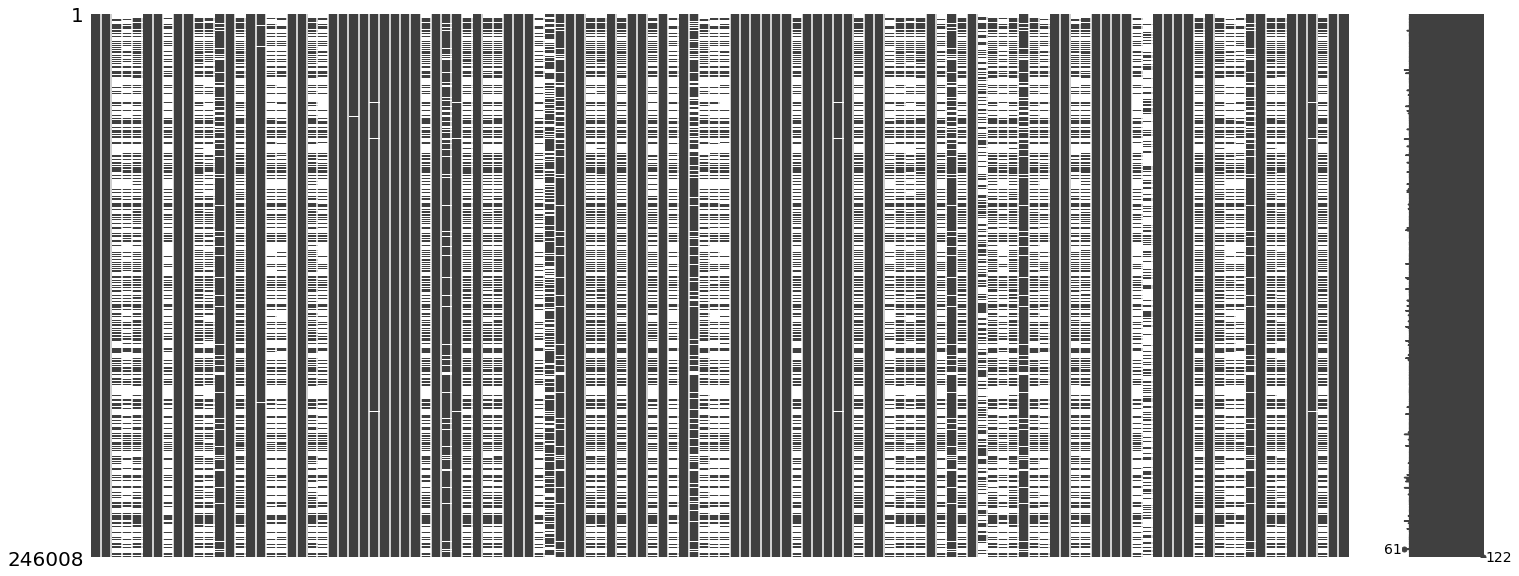

In [22]:
import missingno as msno

# creating a new dataframe that contains only the selected columns with missing values
#missing_data_cols2 = df[missing_cols2]

# using the missingno library to create a visualization of the missing data
msno.matrix(df)

<AxesSubplot:>

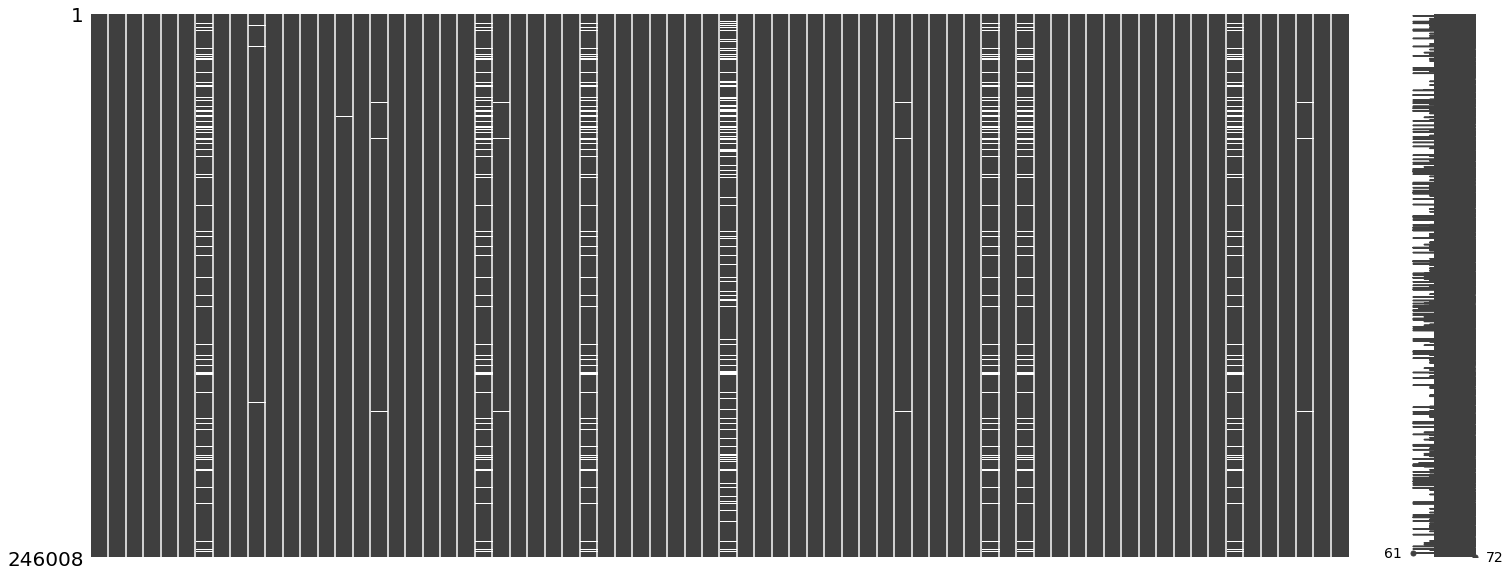

In [23]:
import missingno as msno

# creating a new dataframe that contains only the selected columns with missing values
missing_data_cols2 = df[missing_cols2]

# using the missingno library to create a visualization of the missing data
msno.matrix(missing_data_cols2)

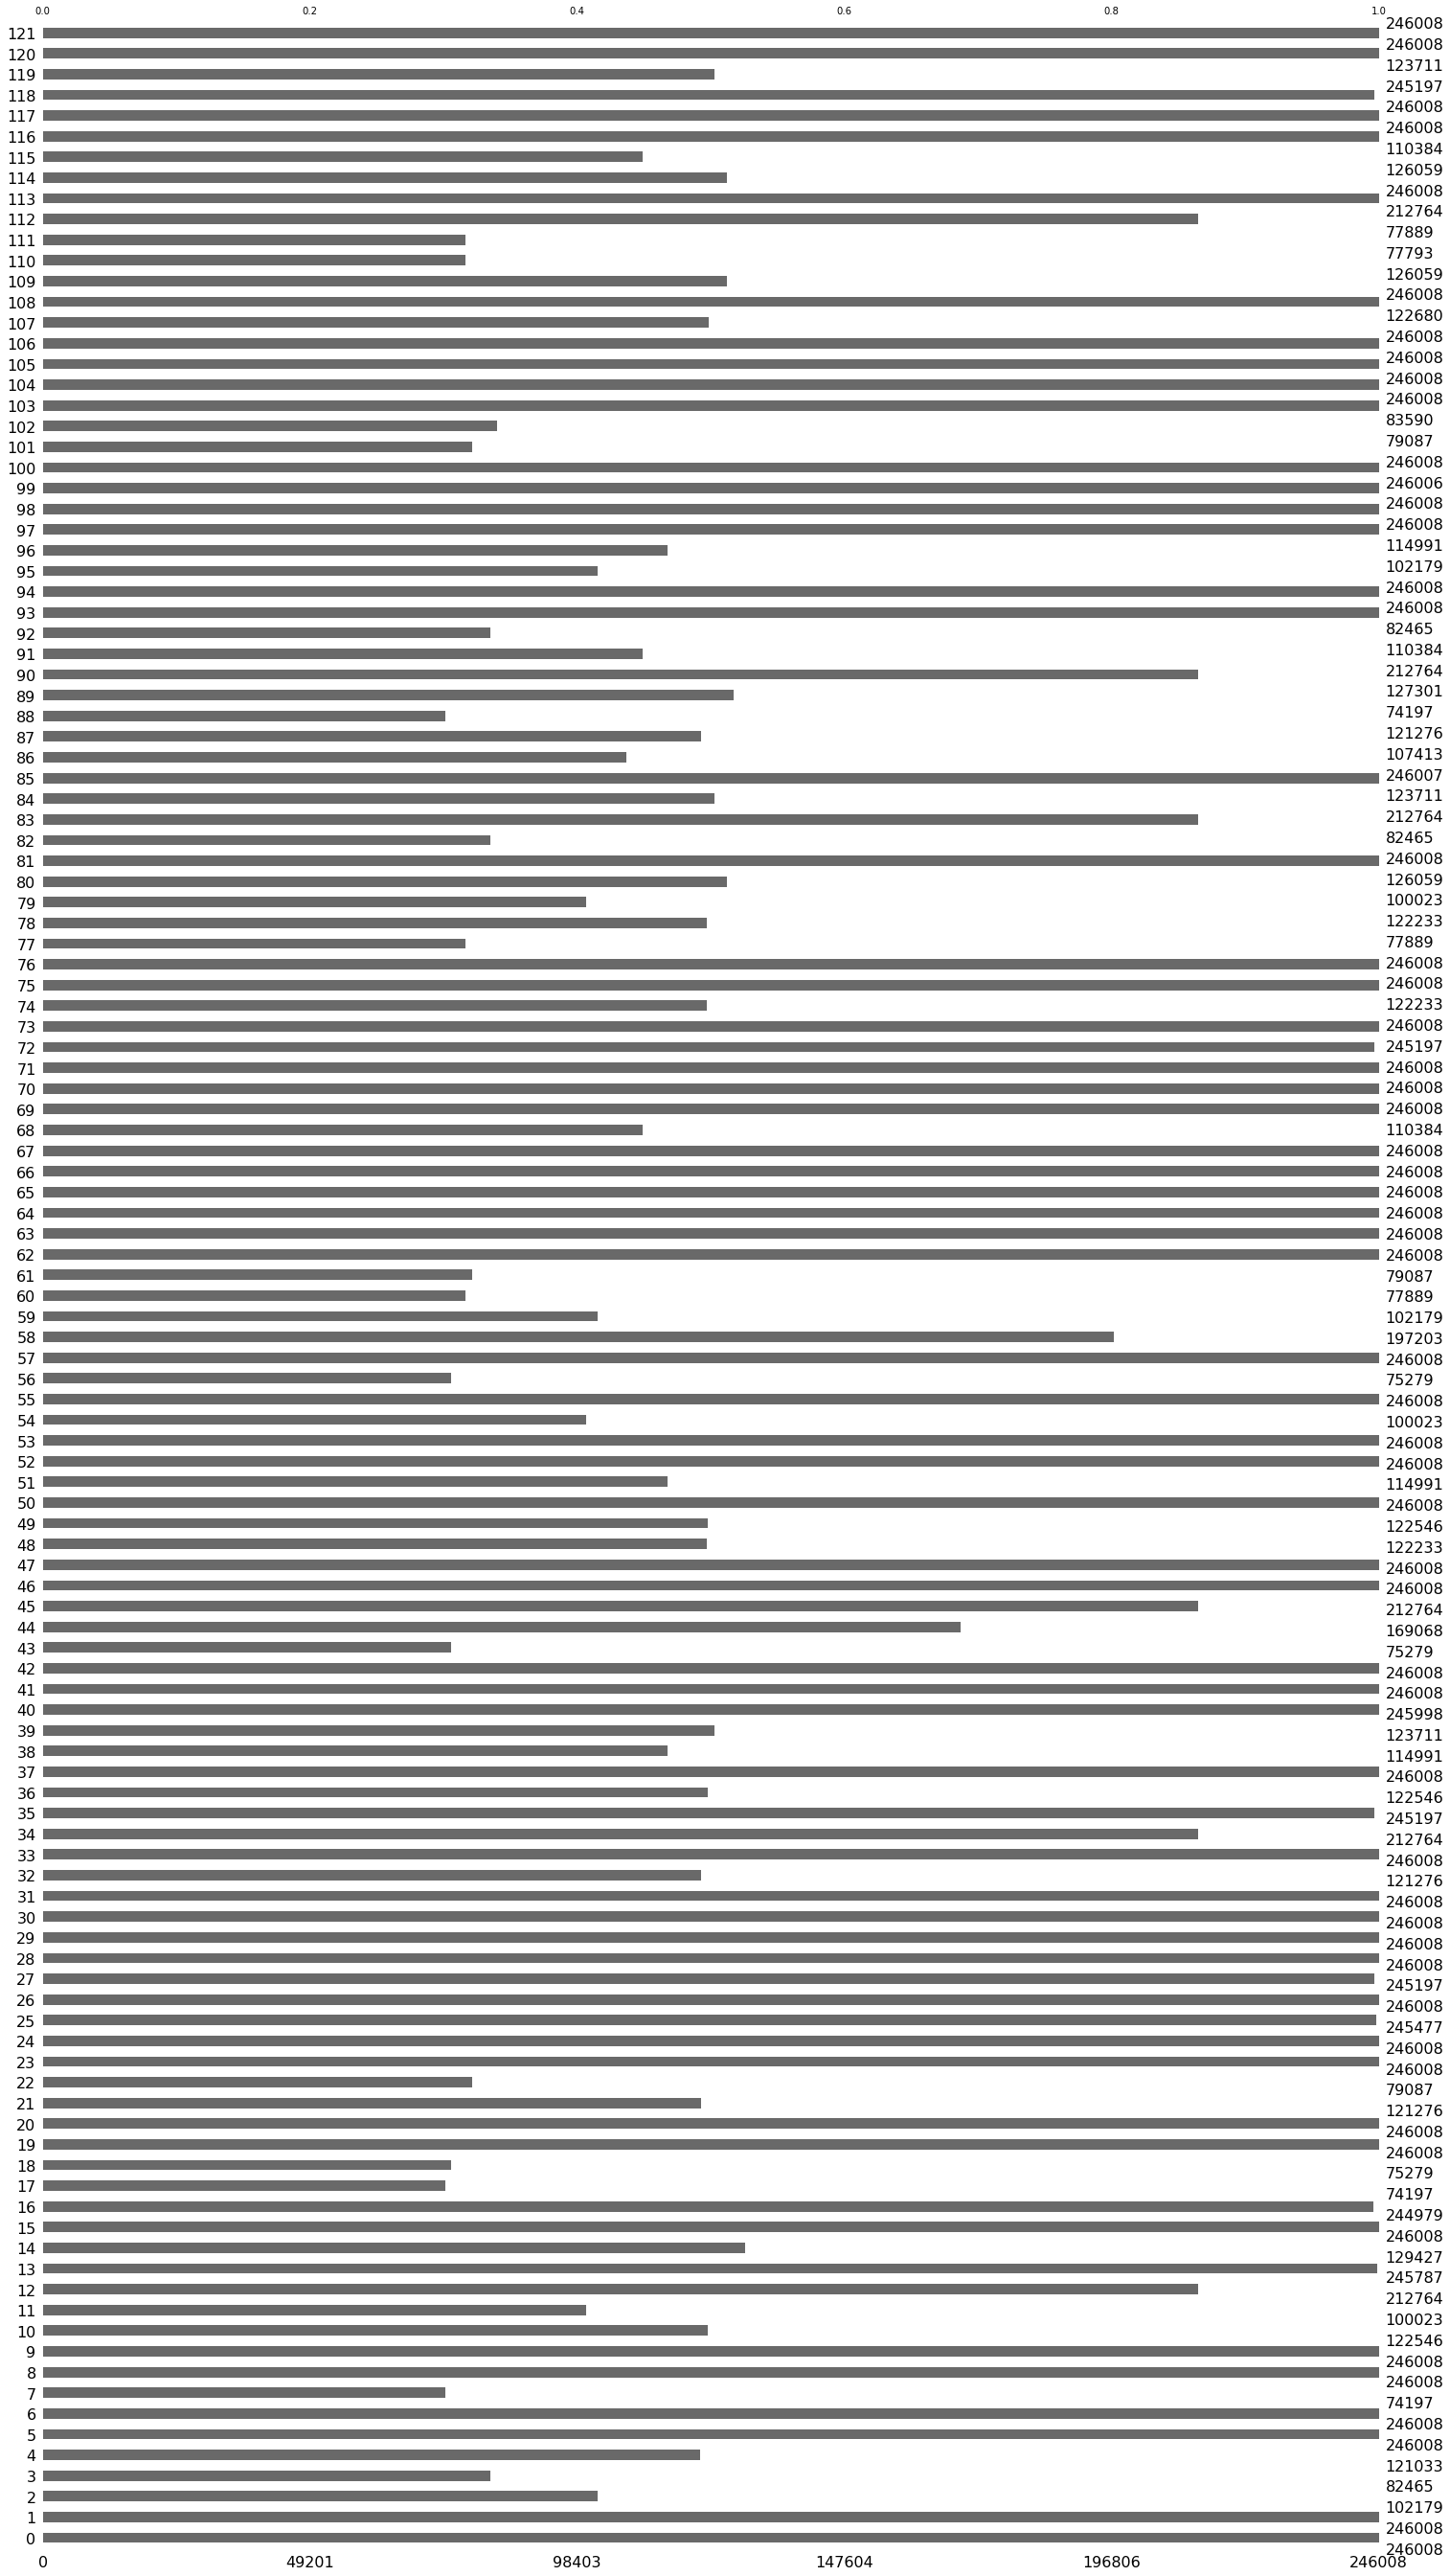

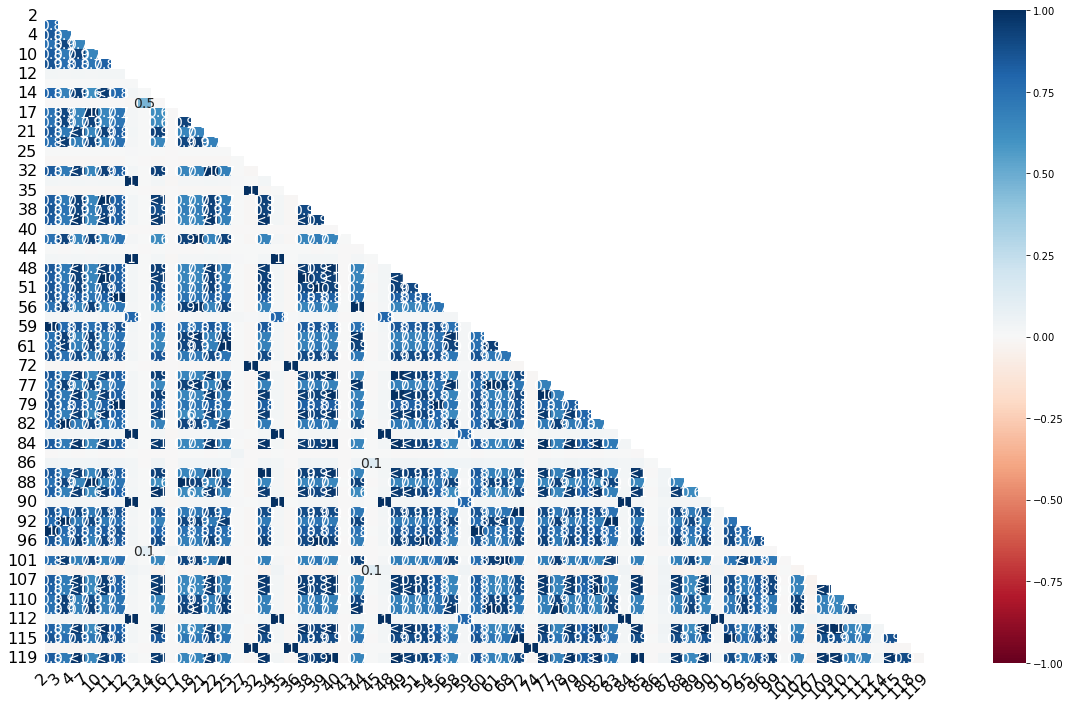

In [25]:
import matplotlib.pyplot as plt


# creating a bar plot of the missing data
msno.bar(df)
plt.show()

# create a heatmap plot of the missing data
msno.heatmap(df)
plt.show()

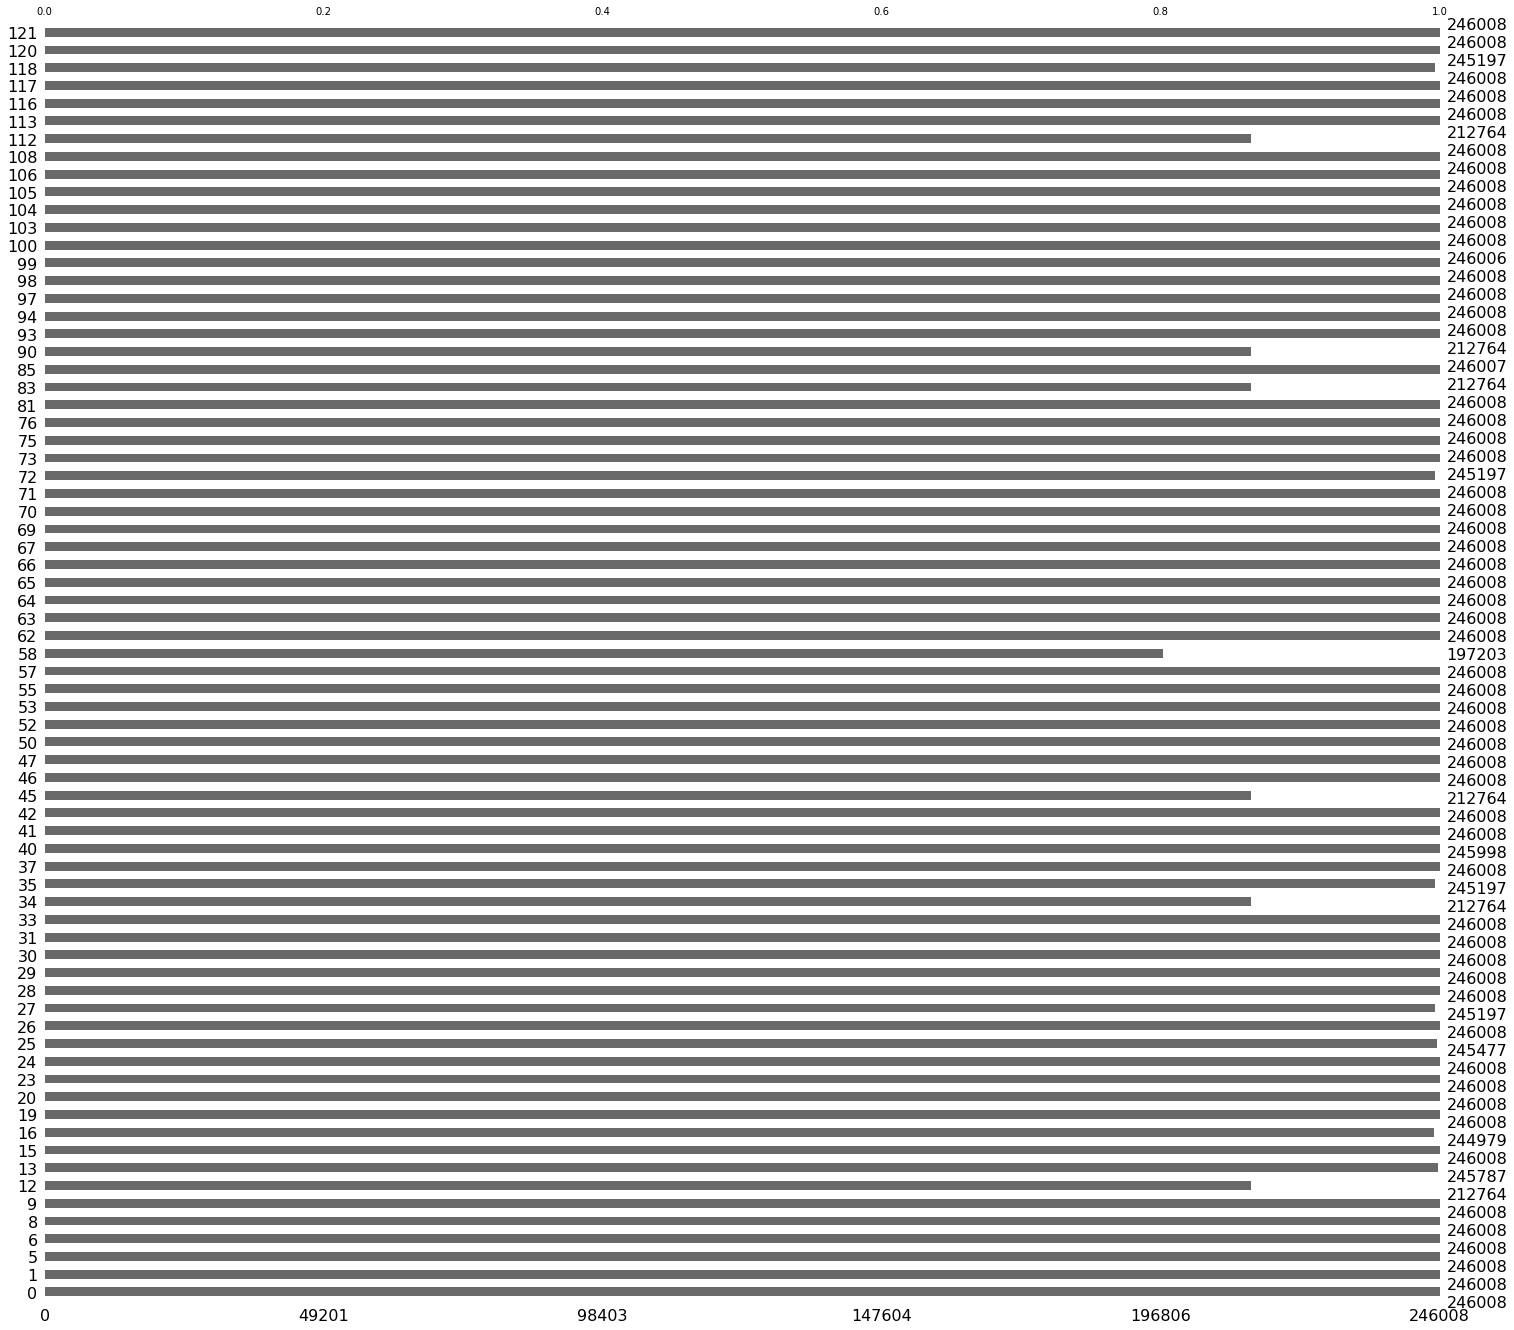

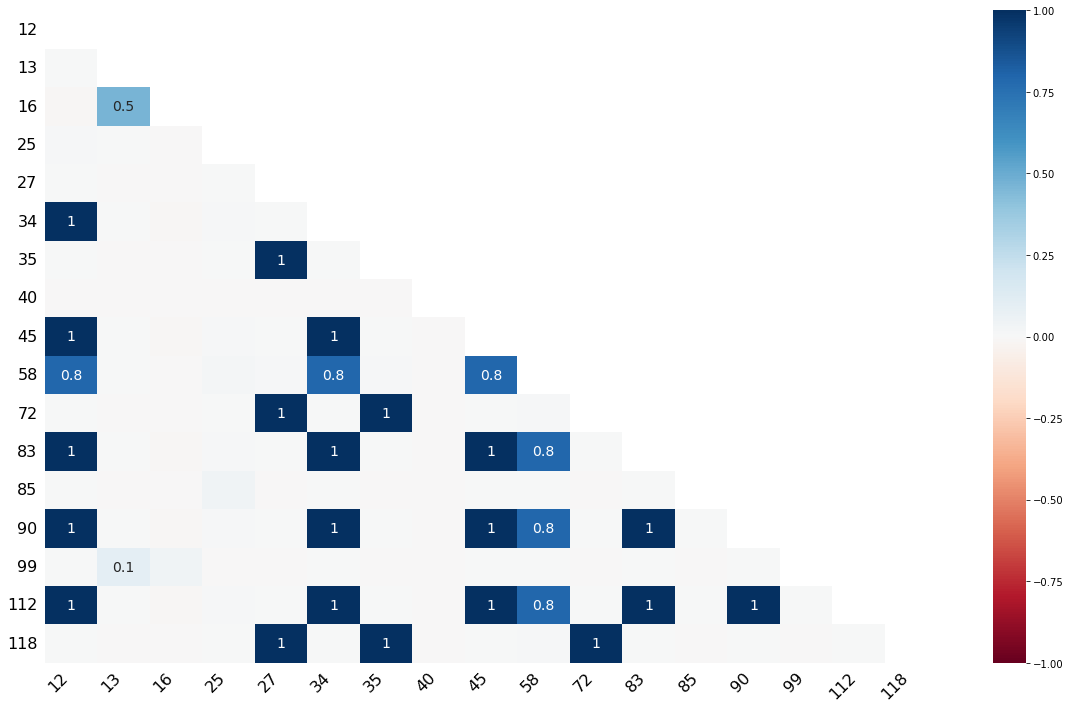

In [24]:
import matplotlib.pyplot as plt


# creating a bar plot of the missing data
msno.bar(missing_data_cols2)
plt.show()

# create a heatmap plot of the missing data
msno.heatmap(missing_data_cols2)
plt.show()

In [26]:
missing_data_cols1 = missing_percent[missing_percent > 0.2].index.tolist()

<AxesSubplot:>

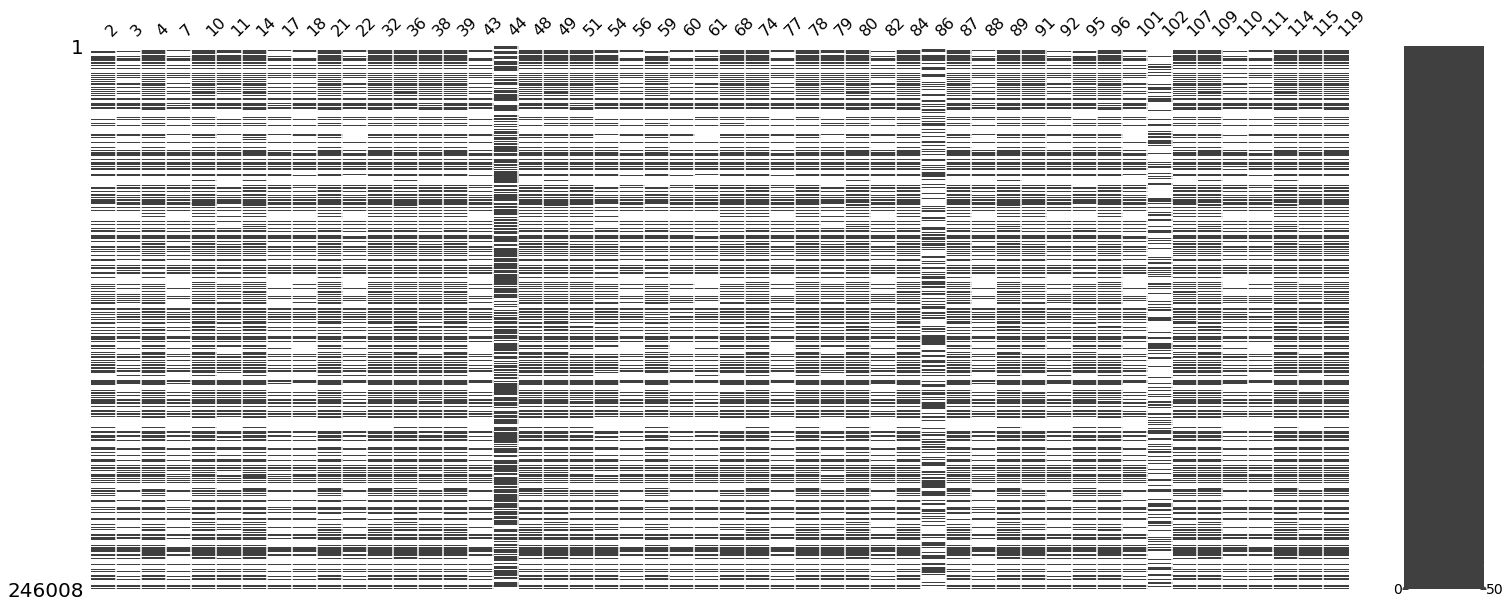

In [27]:
# creating a new dataframe that contains only the selected columns with missing values
missing_data_cols1 = df[missing_data_cols1]

# using the missingno library to create a visualization of the missing data
msno.matrix(missing_data_cols1)

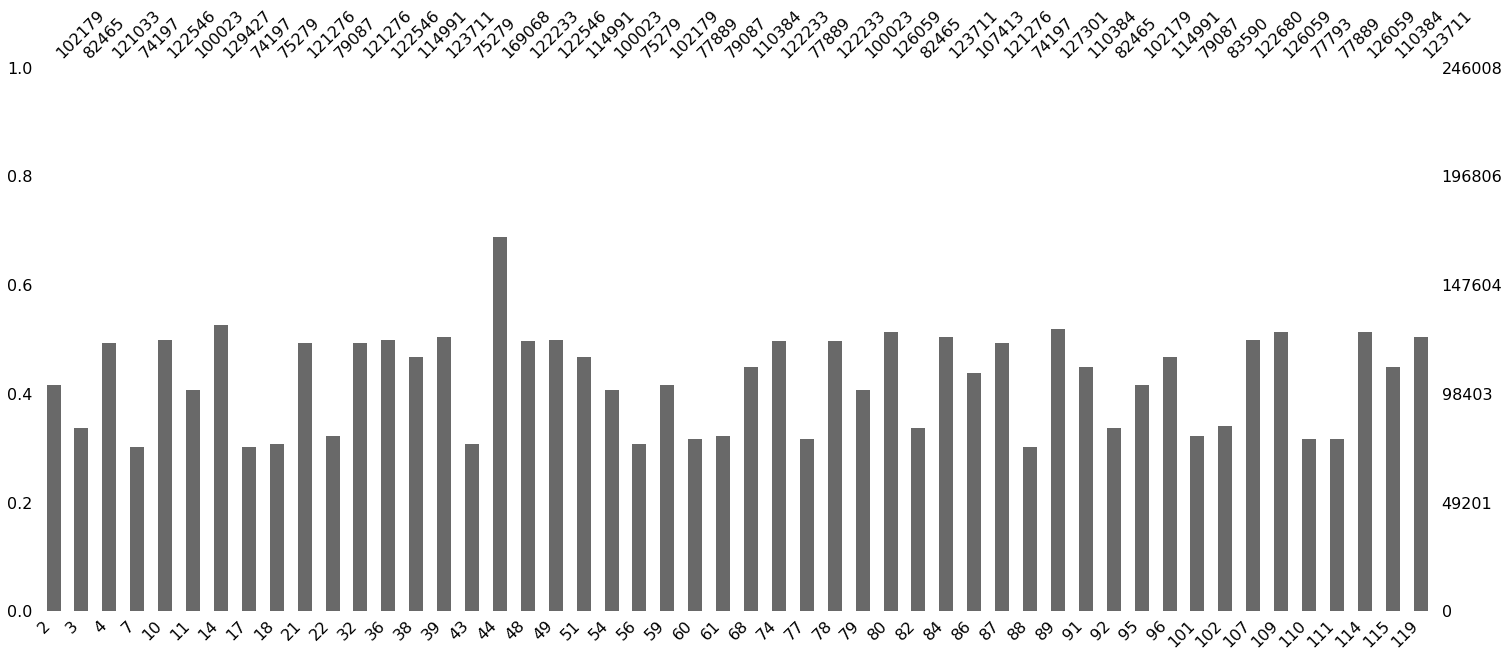

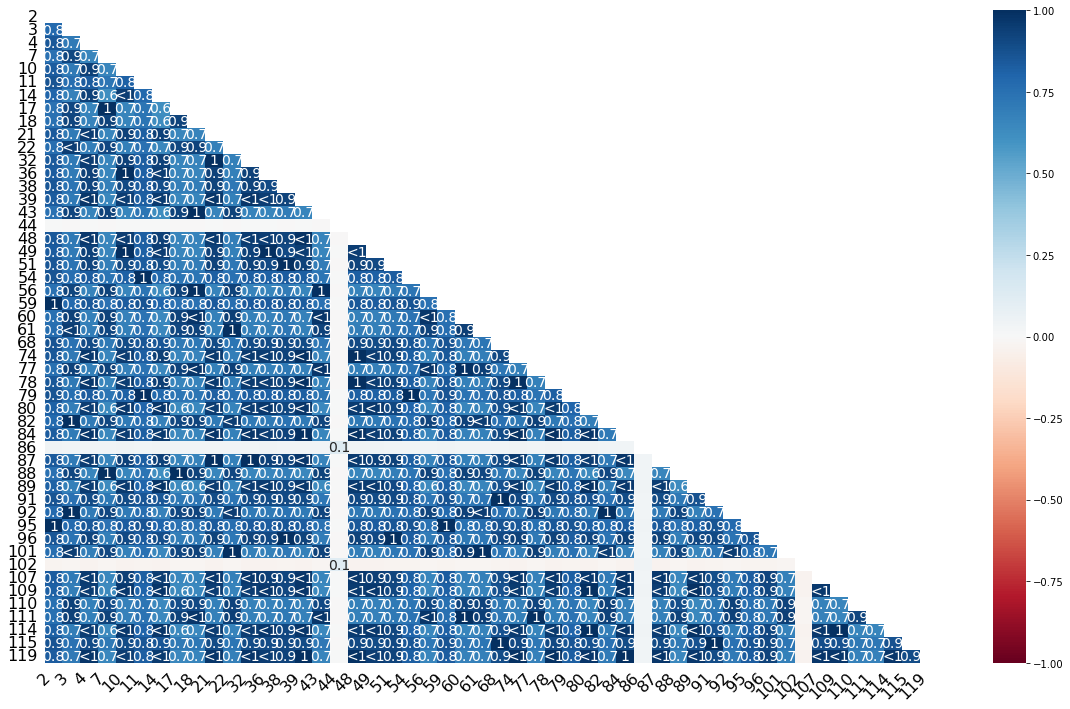

In [28]:
# creating a bar plot of the missing data
msno.bar(missing_data_cols1)
plt.show()

# create a heatmap plot of the missing data
msno.heatmap(missing_data_cols1)
plt.show()

In [29]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

# Print the number of duplicate rows
print("Number of duplicate rows: ", len(duplicate_rows))

# Print the duplicate rows
print(duplicate_rows)


Number of duplicate rows:  0
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
Index: []

[0 rows x 122 columns]


In [166]:
# Transpose the DataFrame
transposed_df = df.transpose()

# Check for duplicate columns
duplicate_columns = transposed_df[transposed_df.duplicated()]

# Print the number of duplicate columns
print("Number of duplicate columns: ", len(duplicate_columns))

# Print the duplicate columns
print(duplicate_columns)

Number of duplicate columns:  0
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
Index: []

[0 rows x 246007 columns]


In [30]:
# Check for duplicate values in the DataFrame
duplicates = df[df.duplicated(keep=False)]

# Print the number of duplicate values
print("Number of duplicate values: ", len(duplicates))

# Print the duplicate values
print(duplicates)

Number of duplicate values:  0
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
Index: []

[0 rows x 122 columns]


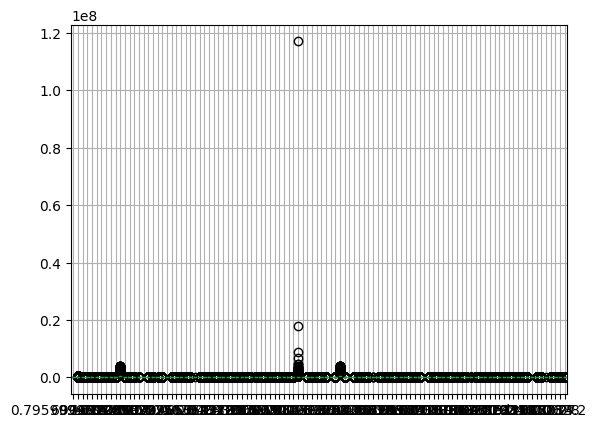

In [168]:
df.boxplot()
plt.show()

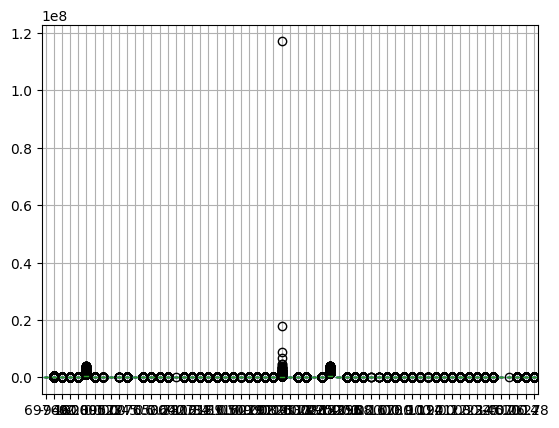

In [172]:
df[missing_cols3].boxplot()
plt.show()

In [177]:
df_filled_mean = df.fillna(df.mean())

<ipython-input-177-046bb2e860e0>:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_filled_mean = df.fillna(df.mean())


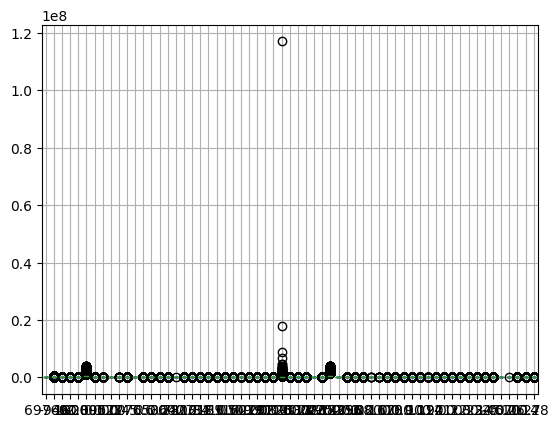

In [178]:
df_filled_mean[missing_cols3].boxplot()
plt.show()

In [179]:
df_filled_median = df.copy()
df_filled_median[missing_cols3] = df_filled_median[missing_cols3].fillna(df_filled_median[missing_cols3].median())

<ipython-input-179-b60234bf0d70>:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_median[missing_cols3] = df_median[missing_cols3].fillna(df_median[missing_cols3].median())


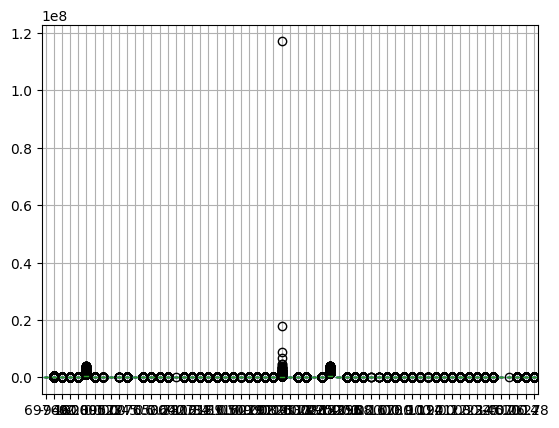

In [180]:
df_filled_median[missing_cols3].boxplot()
plt.show()

In [183]:
string_cols = df.select_dtypes(include=['object']).columns
string_cols

Index(['Panl', 'N', 'Bus2', 'No', 'Unad', 'Come', 'Hout', 'Labs', 'N.1',
       'Hign', 'F', 'WEDY', 'Cass', 'blos', 'regt', 'Mard'],
      dtype='object')

In [188]:
len(string_cols)

16

In [185]:
integer_cols = df.select_dtypes(include=['int']).columns
integer_cols

Index(['69769', '-946', '0', '2', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6',
       '0.7', '0.8', '1', '2.1', '10', '1.1', '0.9', '0.10', '0.11', '0.12',
       '0.13', '1.2', '0.14', '-12298', '0.15', '2.2', '0.16', '0.17', '0.18',
       '0.19', '0.20', '0.21', '0.22', '1.3', '0.23', '0.24', '0.25', '-4670',
       '0.26', '0.27', '0.28'],
      dtype='object')

In [190]:
len(integer_cols)

41

In [187]:
float_cols = df.select_dtypes(include = ['float']).columns
float_cols

Index(['0.1613', '0.7959999999999999', '0.0742', '0.2281', '0.065', '0.0',
       '180000.0', '0.074', '0.0.1', '0.2227', '0.375', '0.2895727653642738',
       '0.0.2', '0.2248', '0.0.3', '0.0.4', '0.2322', '0.32', '0.3333',
       '13189.5', '0.0.5', '1.0', '0.2759', '0.2377', '0.32.1', '0.00823',
       '0.0665', '0.0.6', '90000.0', '0.622922000268356', '0.1613.1', '0.1983',
       '0.375.1', '-6378.0', '227520.0', '0.0.7', '0.0.8', '0.2759.1',
       '0.1816', '0.2759.2', '0.0661', '0.9851', '0.804', '0.0.9', '0.3333.1',
       '0.0.10', '0.38458200387368', '0.2269', '0.0736', '0.2197', '0.0.11',
       '0.0.12', '0.7987', '0.1673', '0.3222', '4.0', '0.375.2',
       'Unnamed: 102', '0.9851.1', '0.1847', '1.0.1', '0.9851.2', '0.0.13',
       '0.0.14', '0.3333.2'],
      dtype='object')

In [191]:
len(float_cols)

65

In [196]:
non_numeric_cols = df.select_dtypes(exclude=['int', 'float', 'object']).columns
non_numeric_cols

Index([], dtype='object')

In [197]:
len(non_numeric_cols)

0

In [199]:
len(float_cols) + len(integer_cols) + len(string_cols) == len(df.columns)

True